# 🍇 Raisin Variety Classification and Model Training

This notebook demonstrates a professional, end-to-end Machine Learning pipeline to classify raisin varieties into **Kecimen** and **Besni** based on their morphological features.

### Dataset Description
The dataset consists of **900 instances** (450 Kecimen and 450 Besni) and **7 morphological features**:
1. **Area**: Number of pixels within the boundaries of the raisin.
2. **Perimeter**: Distance around the boundary of the raisin.
3. **MajorAxisLength**: Length of the main axis.
4. **MinorAxisLength**: Length of the minor axis.
5. **Eccentricity**: Eccentricity of the ellipse.
6. **ConvexArea**: Number of pixels in the smallest convex shell.
7. **Extent**: Ratio of the raisin region area to its bounding box area.

---

## 1. Environment Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [2]:
# Load dataset
df = pd.read_csv("raisin.csv")

# Display dataset summary
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (900, 8)


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524.0,442.246011,253.291155,0.819738,90546.0,0.758651,1184.040,Kecimen
1,75166.0,406.690687,243.032436,0.801805,78789.0,0.684130,1121.786,Kecimen
2,90856.0,442.267048,266.328318,0.798354,93717.0,0.637613,1208.575,Kecimen
3,45928.0,286.540559,208.760042,0.684989,47336.0,0.699599,844.162,Kecimen
4,79408.0,352.190770,290.827533,0.564011,81463.0,0.792772,1073.251,Kecimen


## 2. Exploratory Data Analysis (EDA)
Let's explore the class balance, descriptive statistics, feature distributions, and correlations.

Class
Kecimen    450
Besni      450
Name: count, dtype: int64


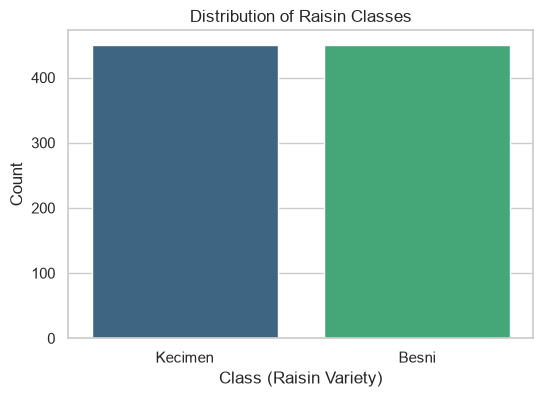

In [3]:
# Check class balance
class_counts = df['Class'].value_counts()
print(class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class', hue='Class', palette='viridis', legend=False)
plt.title('Distribution of Raisin Classes')
plt.xlabel('Class (Raisin Variety)')
plt.ylabel('Count')
plt.show()

In [4]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,900.0,87804.127778,39002.111390,25387.000000,59348.000000,78902.000000,105028.250000,235047.000000
MajorAxisLength,900.0,430.929950,116.035121,225.629541,345.442898,407.803951,494.187014,997.291941
MinorAxisLength,900.0,254.488133,49.988902,143.710872,219.111126,247.848409,279.888575,492.275279
Eccentricity,900.0,0.781542,0.090318,0.348730,0.741766,0.798846,0.842571,0.962124
ConvexArea,900.0,91186.090000,40769.290132,26139.000000,61513.250000,81651.000000,108375.750000,278217.000000
Extent,900.0,0.699508,0.053468,0.379856,0.670869,0.707367,0.734991,0.835455
Perimeter,900.0,1165.906636,273.764315,619.074000,966.410750,1119.509000,1308.389750,2697.753000


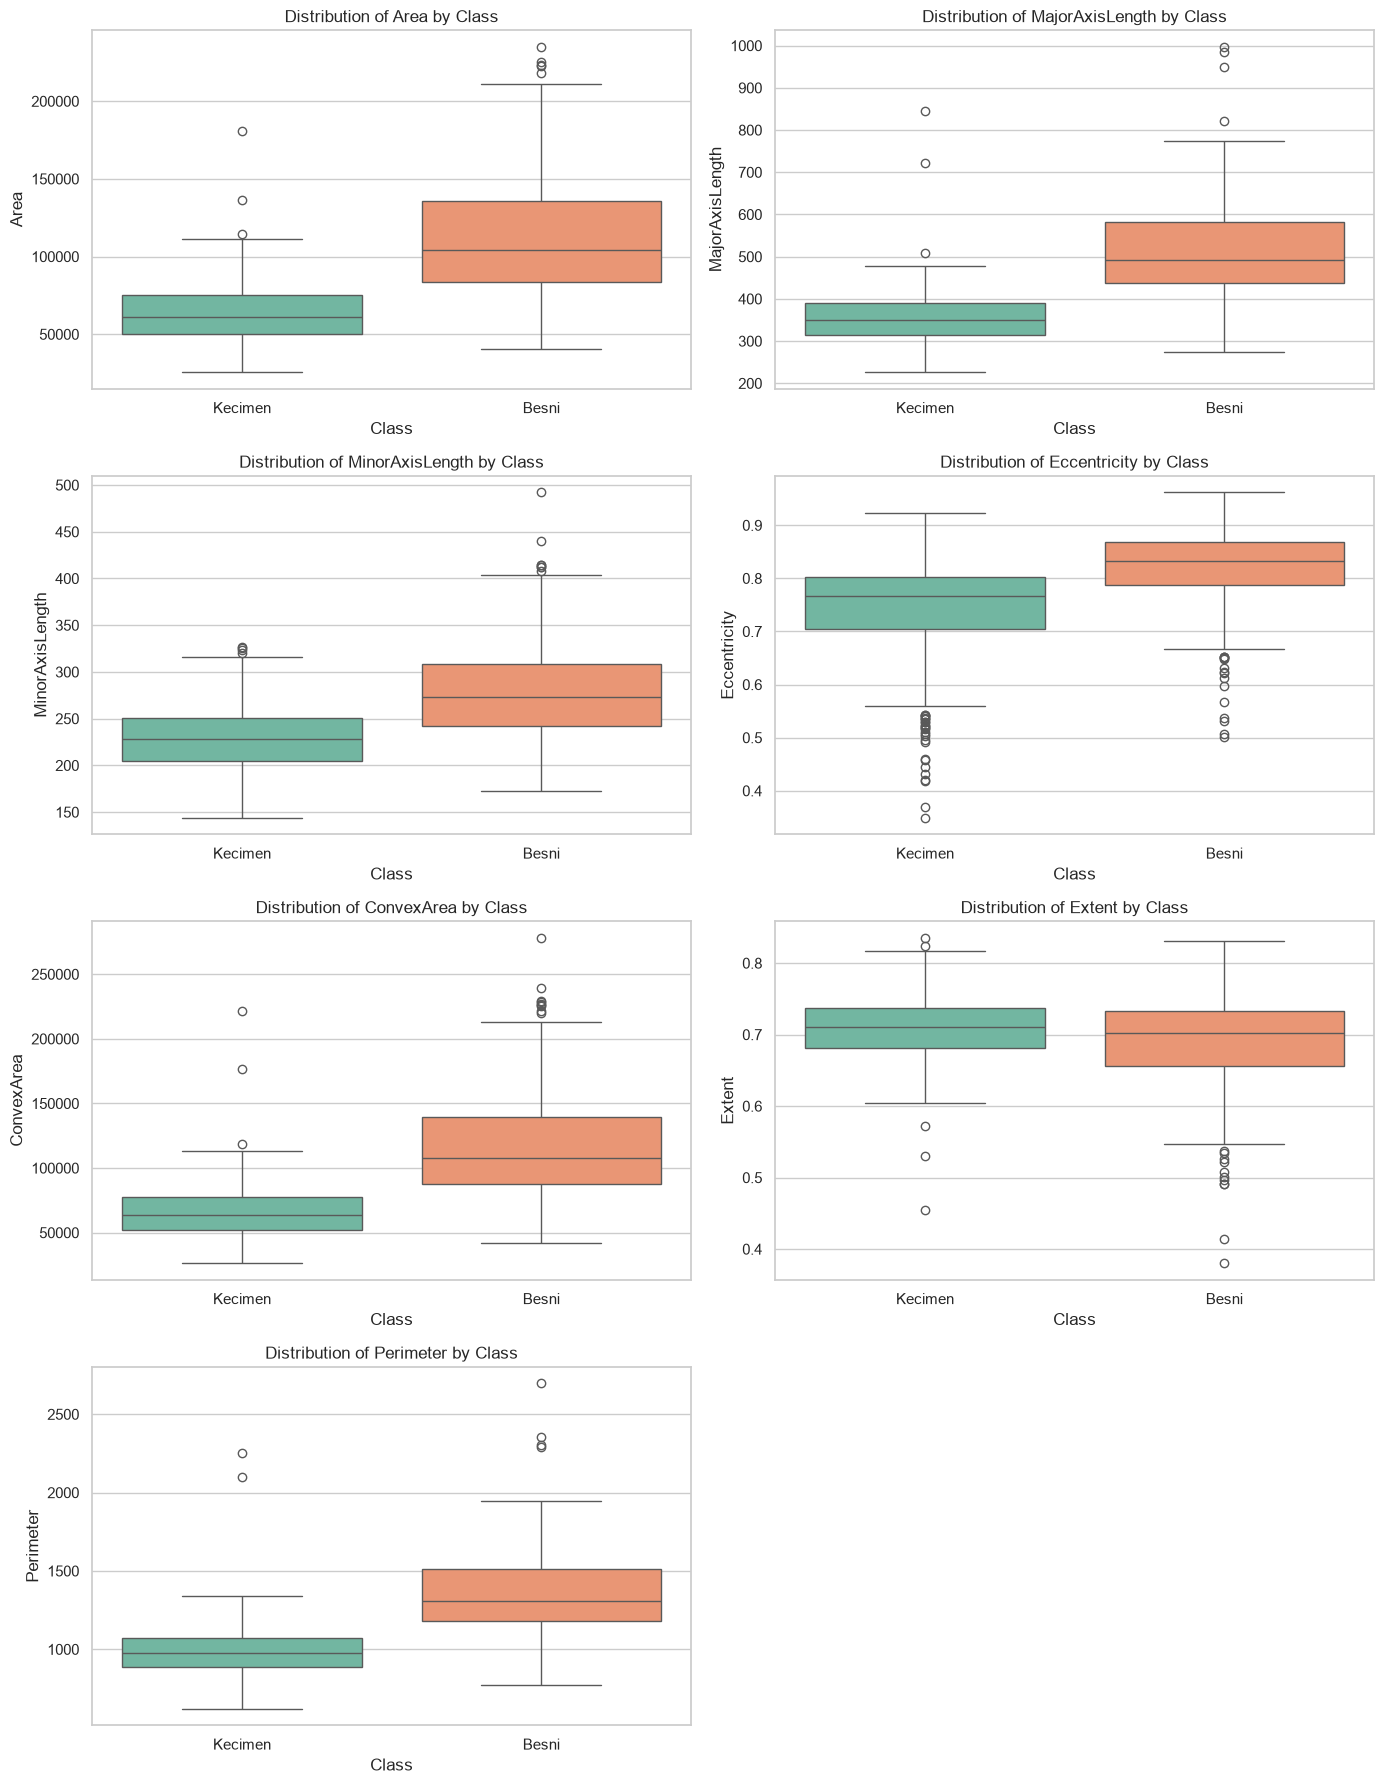

In [5]:
# Feature distribution analysis by Class
features = df.drop('Class', axis=1).columns
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='Class', y=col, ax=axes[i], palette='Set2', hue='Class', legend=False)
    axes[i].set_title(f'Distribution of {col} by Class')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel(col)

# Remove empty subplot
if len(features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

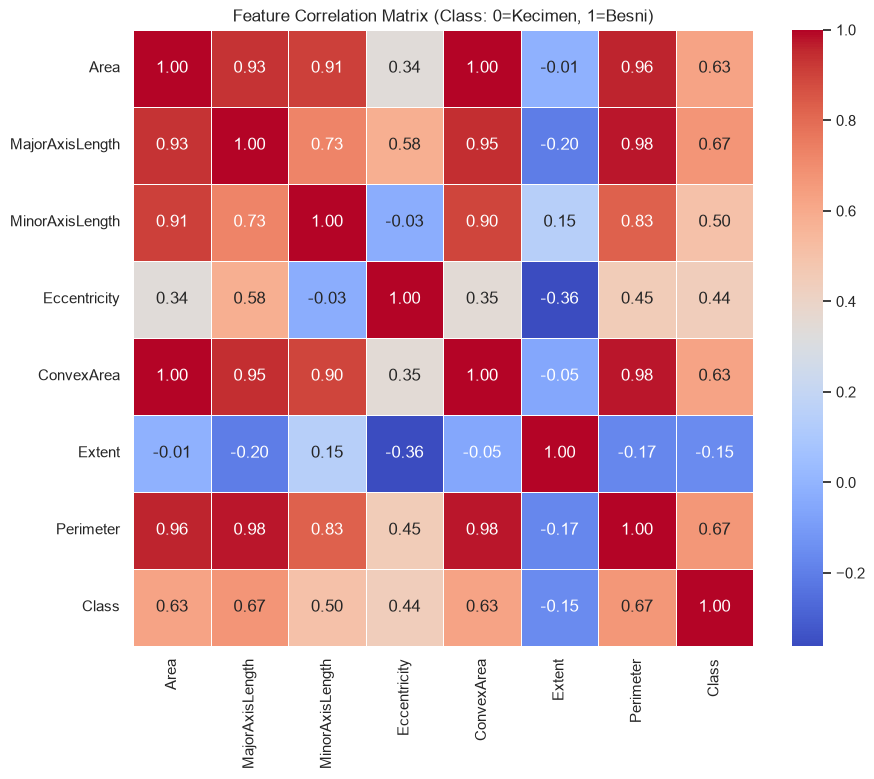

In [6]:
# Correlation Heatmap (encoding target class to include in analysis)
df_encoded = df.copy()
df_encoded['Class'] = df_encoded['Class'].map({'Kecimen': 0, 'Besni': 1})

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix (Class: 0=Kecimen, 1=Besni)')
plt.show()

## 3. Dataset Preprocessing & Splitting

In [7]:
# Split into features (X) and target (y)
X = df.drop("Class", axis=1)
y = df["Class"]

# Perform Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (720, 7)
Testing set shape: (180, 7)


## 4. Model Training & Parameter Configurations

In [8]:
# Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## 5. Model Evaluation

In [9]:
# Predict on test set
y_pred = model.predict(X_test)

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

       Besni       0.93      0.79      0.86        90
     Kecimen       0.82      0.94      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



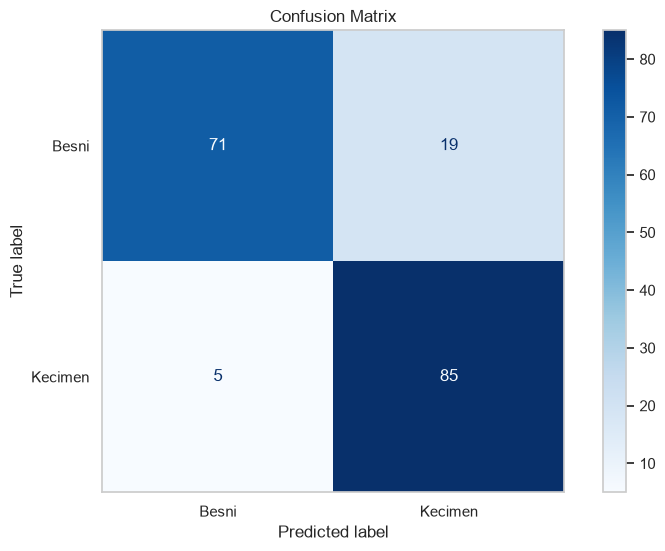

In [10]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

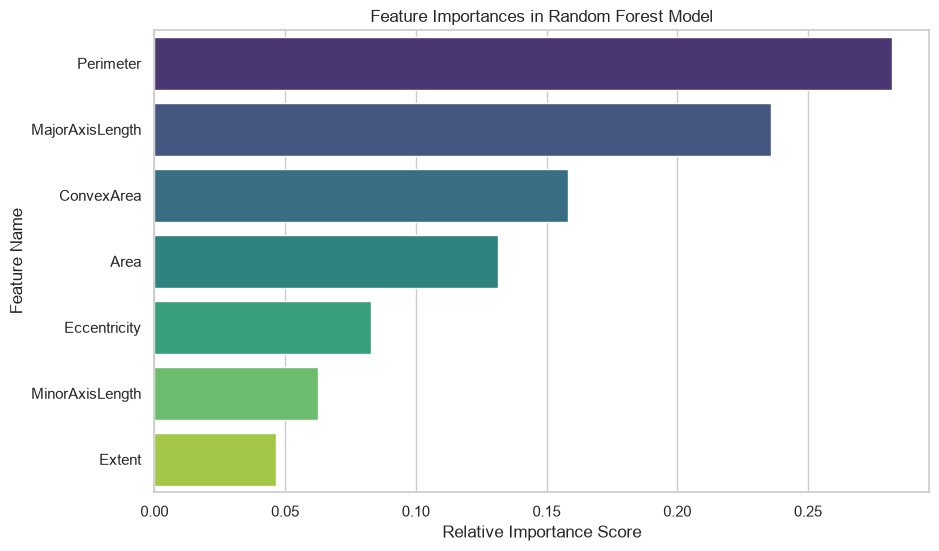

In [11]:
# Feature Importance Analysis
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis', hue=feature_names[indices], legend=False)
plt.title('Feature Importances in Random Forest Model')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Name')
plt.show()

## 6. Model Serialization (Saving Model)

In [12]:
# Save trained model
model_filename = "raisin_model.pkl"
with open(model_filename, "wb") as f:
    pickle.dump(model, f)

print(f"Model successfully serialized and saved to {model_filename}!")

Model successfully serialized and saved to raisin_model.pkl!
